In [186]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad

In [187]:
# constants
k = 2*np.pi/10**-7 #per metre wave number for 100 nm wavelength
Ag = 9.81/2 #m/s^2 acceleration due to gravity/2
Ang = 0 #no gravity case
L = 1e-2 #metre interferometer length
T = 100 #Kelvin temperature
z= 2.18175054*10**-6/T #squared metre per second squared, with T in Kelvin
C = 2.0 #dimensionless constant for contrast adjustment

Vmin = 0.1      # IMPORTANT
Vmax = 10**6  # safe because of exp(-z v^2)

def f_maxwell(v):
    return np.sqrt(z) * np.exp(-z * v**2) * 2 / np.sqrt(np.pi)

def f_dirac(v):
    v0 = 2175 #metres per second #muonium velocity
    delta = 10 #dirac width
    if v0 - delta <= v <= v0 + delta:
        return 1/(2*delta)
    else:
        return 0.0
    
def f_gaussian(v):
    v0 = 2175 #metres per second #muonium velocity
    sigma = 100 #metres per second
    return 1/(sigma * np.sqrt(2*np.pi)) * np.exp(-0.5 * ((v - v0)/sigma)**2)

def integrand(v, x, f=f_maxwell, A=Ag):
    phase = k*x + k*A*(L/v)**2
    return f(v) * (np.cos(phase) + C)

def g(x, f=f_maxwell, vmin=Vmin, vmax=Vmax, A=Ag):
    val, err = quad(integrand, vmin, vmax, args=(x, f, A), limit=200)
    return val

def int_f(f, vmin, vmax=10**6):
    val, err = quad(
        f,
        vmin,
        vmax,
        points=[2175 - 10, 2175 + 10],
        epsabs=1e-12,
        epsrel=1e-10,
        limit=1000
    )
    return val


    return val


Maxwell normalization: 0.9999833329934789
Dirac normalization: 1.0
Gaussian normalization: 0.9999999999999996


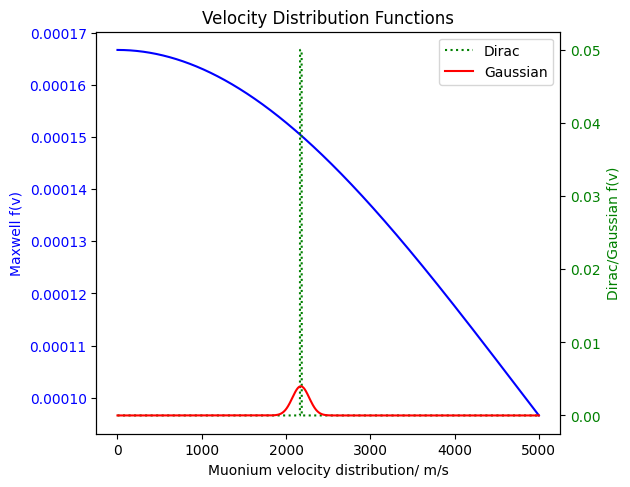

In [188]:
#check the normalisation
print("Maxwell normalization:", int_f(f_maxwell, Vmin, 10**6))
print("Dirac normalization:", int_f(f_dirac, Vmin, 5000))
print("Gaussian normalization:", int_f(f_gaussian, Vmin, 5000))

#plot f(x) values for testing
vs = np.linspace(Vmin, 5000, 40000)
fs_maxwell = np.array([f_maxwell(v) for v in vs])
fs_dirac = np.array([f_dirac(v) for v in vs])
fs_gaussian = np.array([f_gaussian(v) for v in vs])

#plot maxwell on a separate axis
fig, ax1 = plt.subplots()

ax1.plot(vs, fs_maxwell, label="Maxwell", color='blue')
ax1.set_xlabel("Muonium velocity distribution/ m/s")
ax1.set_ylabel("Maxwell f(v)", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(vs, fs_dirac, label="Dirac", color='green', linestyle='dotted')
ax2.plot(vs, fs_gaussian, label="Gaussian", color='red')
ax2.set_ylabel("Dirac/Gaussian f(v)", color='green')
ax2.tick_params(axis='y', labelcolor='green')

fig.tight_layout()
plt.title("Velocity Distribution Functions")
plt.legend(loc="upper right")
plt.show()

Watch out this is a 1D velocity distribution because of the traversal time: https://en.wikipedia.org/wiki/Maxwell%E2%80%93Boltzmann_distribution
Not speed, not 3D velocity.

/var/folders/v8/f7ff7bzn66z3q5_fw16grwb80000gn/T/ipykernel_10087/473670675.py:34: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, err = quad(integrand, vmin, vmax, args=(x, f, A), limit=200)


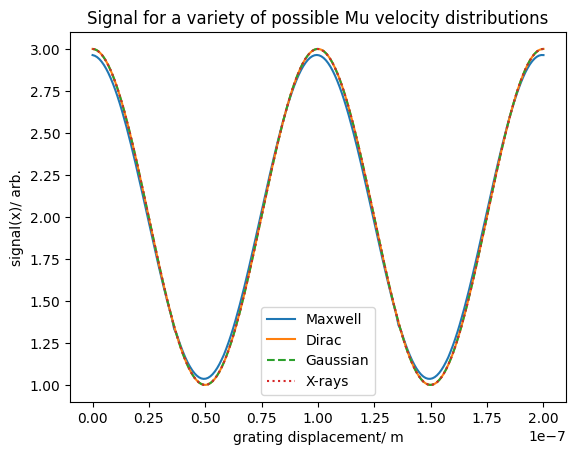

In [189]:
xs = np.linspace(0, 0.2*10**-6, 200)
ys_maxwell = np.array([g(x, f_maxwell, vmax=10**6) for x in xs])
ys_dirac = np.array([g(x, f_dirac, vmin=2100,vmax=2200) for x in xs])
ys_gaussian = np.array([g(x, f_gaussian, vmax=10000) for x in xs])
#no gravity
ys_gaussian_ng = np.array([g(x, f_dirac, vmin=2100,vmax=2200, A=Ang) for x in xs])


plt.plot(xs, ys_maxwell, label="Maxwell")
plt.plot(xs, ys_dirac, label="Dirac")
plt.plot(xs, ys_gaussian, label="Gaussian", linestyle='dashed')
plt.plot(xs, ys_gaussian, label='X-rays', linestyle='dotted')
plt.xlabel("grating displacement/ m")
plt.ylabel("signal(x)/ arb.")
plt.title("Signal for a variety of possible Mu velocity distributions")
plt.legend()    
plt.show()


/var/folders/v8/f7ff7bzn66z3q5_fw16grwb80000gn/T/ipykernel_10087/473670675.py:34: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, err = quad(integrand, vmin, vmax, args=(x, f, A), limit=200)


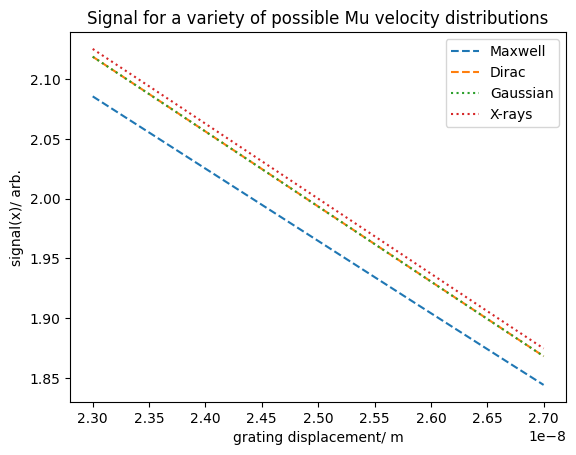

In [190]:
delta = 2 * 10**-9
position =25.0 * 10**-9
xs = np.linspace(position - delta, position + delta, 200)
ys_maxwell = np.array([g(x, f_maxwell, vmax=10**6, A=Ag) for x in xs])
ys_dirac = np.array([g(x, f_dirac, vmin=2100,vmax=2200, A=Ag) for x in xs])
ys_gaussian = np.array([g(x, f_gaussian, vmax=10000, A=Ag) for x in xs])
ys_nogravity = np.array([g(x, f_dirac, vmin=2100,vmax=2200, A=Ang) for x in xs])


plt.plot(xs, ys_maxwell, label="Maxwell", linestyle='dashed')
plt.plot(xs, ys_dirac, label="Dirac", linestyle='dashed')
plt.plot(xs, ys_gaussian, label="Gaussian", linestyle='dotted')
plt.plot(xs, ys_nogravity, label="X-rays", linestyle='dotted')
plt.xlabel("grating displacement/ m")
plt.ylabel("signal(x)/ arb.")
plt.title("Signal for a variety of possible Mu velocity distributions")
plt.legend()    
plt.show()


/var/folders/v8/f7ff7bzn66z3q5_fw16grwb80000gn/T/ipykernel_10087/473670675.py:34: IntegrationWarning: The maximum number of subdivisions (200) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  val, err = quad(integrand, vmin, vmax, args=(x, f, A), limit=200)


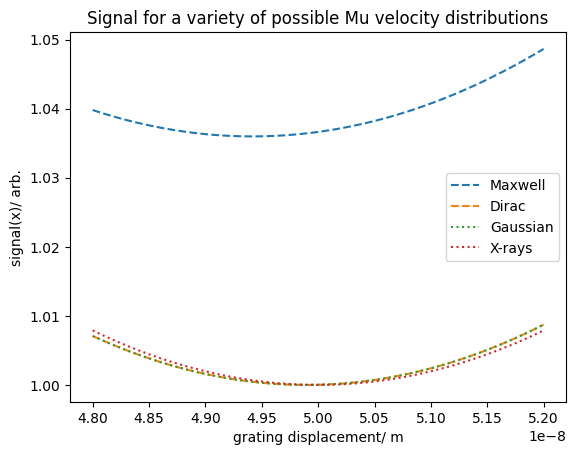

In [191]:
delta = 2 * 10**-9
position =50.0 * 10**-9
xs = np.linspace(position - delta, position + delta, 200)
ys_maxwell = np.array([g(x, f_maxwell, vmax=10**6, A=Ag) for x in xs])
ys_dirac = np.array([g(x, f_dirac, vmin=2100,vmax=2200, A=Ag) for x in xs])
ys_gaussian = np.array([g(x, f_gaussian, vmax=10000, A=Ag) for x in xs])
ys_nogravity = np.array([g(x, f_dirac, vmin=2100,vmax=2200, A=Ang) for x in xs])


plt.plot(xs, ys_maxwell, label="Maxwell", linestyle='dashed')
plt.plot(xs, ys_dirac, label="Dirac", linestyle='dashed')
plt.plot(xs, ys_gaussian, label="Gaussian", linestyle='dotted')
plt.plot(xs, ys_nogravity, label="X-rays", linestyle='dotted')
plt.xlabel("grating displacement/ m")
plt.ylabel("signal(x)/ arb.")
plt.title("Signal for a variety of possible Mu velocity distributions")
plt.legend()    
plt.show()
